# PHASE 6 — YOLO Detection Head
## Multimodal Maritime Object Detection Using SAR and Optical Satellite Imagery
---
**Team 22UG0005 | Panel No. 5 | Guide: Mr. Nagesh Koundinya Subbanna**

---
## WHAT IS PHASE 6?

Phase 6 is the FINAL prediction layer of the model.
It takes the fused feature maps from Phase 5 and produces
actual ship detections — bounding boxes with confidence scores.

---
## WHERE IS THE MODEL ACTUALLY TRAINED?

This is an important question. Here is the FULL picture:

```
PHASES 0-2: Data preparation (done ONCE, before training)
  Phase 0: rename images, generate SAR, fix CSV
  Phase 1: preprocess all images, save to disk
  Phase 2: decode RLE masks, generate YOLO .txt labels

PHASE 3: Build DataLoader (done ONCE, before training)
  Stratified 10,000 image subset
  train_loader (9,000 images) + val_loader (1,000 images)

PHASES 4, 5, 6: Define the MODEL ARCHITECTURE
  Phase 4: ResNet50 (SAR) + CSPDarknet (optical) backbones
  Phase 5: CrossModalAttention + FPN fusion neck
  Phase 6: YOLO detection heads  <- YOU ARE HERE

PHASE 7 (next): TRAINING LOOP  <- WHERE LEARNING HAPPENS
  The model from Phases 4+5+6 is trained on the data from Phase 3
  Loss = L_cls + L_bbox + L_obj is minimised over 20 epochs
  The model LEARNS to detect ships from the 9,000 training images
  Validation mAP is measured on 1,000 val images each epoch
  Best checkpoint is saved

PHASE 8: Evaluation on the val set (mAP@0.5, Precision, Recall)
PHASE 9: Inference on new test images
```

So: Phases 4, 5, 6 DEFINE the model. Phase 7 TRAINS it.
The dataset used is from Phase 2: 193,460 annotated image pairs.

---
## WHAT IS THE YOLO DETECTION HEAD?

The detection head is what converts abstract feature maps
into concrete predictions: 'there is a ship at (x, y) with width w, height h'.

```
CONCEPT: Divide the image into a grid.
         Each grid cell can predict ships.
         Each cell has 3 anchor boxes (pre-defined ship shapes).
         For each anchor, predict: is there a ship? where? how big?
```

---
## WHY THREE HEADS AT P3, P4, P5?

```
P3 head (stride 8,  grid 40x40):
  40x40 = 1,600 grid cells
  Each cell is 8x8 pixels
  Small anchors -> detects SMALL ships (5-20px)
  Ships far away in satellite view

P4 head (stride 16, grid 20x20):
  20x20 = 400 grid cells
  Each cell is 16x16 pixels
  Medium anchors -> detects TYPICAL vessels (20-60px)
  Most common ship sizes in the dataset

P5 head (stride 32, grid 10x10):
  10x10 = 100 grid cells
  Each cell is 32x32 pixels
  Large anchors -> detects LARGE ships (60px+)
  Supertankers, aircraft carriers
```

---
## WHAT DOES EACH HEAD OUTPUT?

```
Each head outputs: [B, 3 x (5 + 1), H_grid, W_grid]

Breaking down 3 x 6 = 18:
  3        = NUM_ANCHORS (3 pre-defined ship shapes)
  5 + 1    = 5 box values + 1 class value

The 5 box values for each anchor:
  tx : x offset from grid cell centre  (relative, 0-1)
  ty : y offset from grid cell centre  (relative, 0-1)
  tw : log(width  / anchor_width)      (raw regression)
  th : log(height / anchor_height)     (raw regression)
  obj: objectness score (is there a ship here?) 0-1

The 1 class value:
  cls: ship confidence (class 0 = ship) 0-1

Decoding at inference:
  x_center = (sigmoid(tx) + cell_x) * stride
  y_center = (sigmoid(ty) + cell_y) * stride
  width    = anchor_w * exp(tw)
  height   = anchor_h * exp(th)
  conf     = sigmoid(obj) * sigmoid(cls)
```

---
## EXACT INPUTS (from Phase 5):
```
out_P3 [B, 256, 40, 40]   stride 8
out_P4 [B, 256, 20, 20]   stride 16
out_P5 [B, 256, 10, 10]   stride 32
```

## EXACT OUTPUTS:
```
pred_P3 [B, 18, 40, 40]   3 anchors x 6 values
pred_P4 [B, 18, 20, 20]   3 anchors x 6 values
pred_P5 [B, 18, 10, 10]   3 anchors x 6 values
```

## Cell 1 — Install Libraries

In [1]:
import subprocess, sys
required = ['torch', 'torchvision', 'numpy', 'matplotlib', 'opencv-python']
for pkg in required:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All libraries installed.')

All libraries installed.


## Cell 2 — Imports

In [2]:
import os, sys, io
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
# Fix Windows Unicode printing
if hasattr(sys.stdout, "buffer"):
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8', errors='replace')
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cpu':
    torch.set_num_threads(8)

print('All imports successful.')
print(f'  PyTorch : {torch.__version__}')
print(f'  Device  : {device}')
print(f'  Run at  : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

All imports successful.
  PyTorch : 2.11.0+cpu
  Device  : cpu
  Run at  : 2026-05-01 14:17:05


## Cell 3 — Configuration and Anchor Definition

In [3]:
# =====================================================================
#   EDIT ONLY THIS CELL
# =====================================================================

ROOT         = r'C:\Users\VaishnaviM\Downloads\airbus-ship-detection'
DATA_DIR     = os.path.join( r'C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset')
OUT_DIR      = os.path.join(DATA_DIR, 'phase6_outputs')
SUMMARY_FILE = os.path.join(DATA_DIR, 'phase6_summary.txt')
os.makedirs(OUT_DIR, exist_ok=True)

# -- DIMENSIONS (must match Phases 1, 3, 4, 5) ------------------------
BATCH_SIZE   = 4
IMG_H        = 320
IMG_W        = 320
FEAT_CH      = 256      # FPN output channels from Phase 5

# -- DETECTION SETTINGS -----------------------------------------------
NUM_CLASSES  = 1        # Only one class: ship
NUM_ANCHORS  = 3        # 3 anchor boxes per grid cell per level
# Output per cell: NUM_ANCHORS x (4 box + 1 obj + NUM_CLASSES) = 3x6 = 18
OUT_CH       = NUM_ANCHORS * (5 + NUM_CLASSES)   # = 18

# -- ANCHOR BOXES (width, height in pixels at 320x320) ----------------
# Anchors are pre-defined typical ship sizes at each detection scale.
# These are FIXED during training - the model learns OFFSETS from them.
#
# How anchor sizes are chosen:
#   Analyse the bounding box sizes in the training set.
#   Use k-means clustering to find the 9 most common shapes.
#   Assign 3 smallest to P3, 3 medium to P4, 3 largest to P5.
#
# For maritime ships at 320x320:
#   Small ships (P3)  : 10-30px -> anchors [(10,6), (18,10), (28,16)]
#   Medium ships (P4) : 30-70px -> anchors [(40,24), (55,35), (70,48)]
#   Large ships (P5)  : 70px+   -> anchors [(90,60), (130,85), (180,120)]

ANCHORS = {
    'P3': [(10, 6),   (18, 10),  (28, 16)],    # small  ships, stride 8
    'P4': [(40, 24),  (55, 35),  (70, 48)],    # medium ships, stride 16
    'P5': [(90, 60),  (130, 85), (180, 120)],  # large  ships, stride 32
}
STRIDES = {'P3': 8, 'P4': 16, 'P5': 32}

# -- INFERENCE THRESHOLDS --------------------------------------------
CONF_THRESHOLD = 0.50   # minimum confidence to keep a detection
NMS_IOU_THRESH = 0.45   # IoU threshold for Non-Maximum Suppression

print('Configuration loaded.')
print(f'  Device         : {device}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  Image size     : {IMG_H}x{IMG_W}')
print(f'  FEAT_CH        : {FEAT_CH}  (from Phase 5 FPN)')
print(f'  NUM_CLASSES    : {NUM_CLASSES}  (ship only)')
print(f'  NUM_ANCHORS    : {NUM_ANCHORS}  per grid cell per level')
print(f'  OUT_CH         : {OUT_CH}  (= {NUM_ANCHORS} x (5 + {NUM_CLASSES}))')
print(f'  CONF_THRESHOLD : {CONF_THRESHOLD}')
print(f'  NMS_IOU_THRESH : {NMS_IOU_THRESH}')
print()
print('  Anchor boxes (width x height in pixels at 320x320):')
for level, ancs in ANCHORS.items():
    stride = STRIDES[level]
    grid   = IMG_H // stride
    print(f'    {level} (stride {stride:2d}, grid {grid}x{grid}): {ancs}')

Configuration loaded.
  Device         : cpu
  Batch size     : 4
  Image size     : 320x320
  FEAT_CH        : 256  (from Phase 5 FPN)
  NUM_CLASSES    : 1  (ship only)
  NUM_ANCHORS    : 3  per grid cell per level
  OUT_CH         : 18  (= 3 x (5 + 1))
  CONF_THRESHOLD : 0.5
  NMS_IOU_THRESH : 0.45

  Anchor boxes (width x height in pixels at 320x320):
    P3 (stride  8, grid 40x40): [(10, 6), (18, 10), (28, 16)]
    P4 (stride 16, grid 20x20): [(40, 24), (55, 35), (70, 48)]
    P5 (stride 32, grid 10x10): [(90, 60), (130, 85), (180, 120)]


## Cell 4 — Single Detection Head Module

In [4]:
# =====================================================================
#  YOLOHead — Single Detection Head for One Pyramid Level
#
#  This is the simplest part of the whole model.
#  It is just: 3x3 conv -> 1x1 conv -> raw predictions
#
#  WHY TWO CONVOLUTIONS?
#  The 3x3 conv: aggregates spatial context from neighbouring cells
#                (a ship that overlaps multiple grid cells)
#  The 1x1 conv: maps to exact output channels (18 = 3 x 6)
#                without mixing spatial information
#
#  THE OUTPUT IS RAW (not sigmoid, not softmax).
#  During training, loss functions apply their own activations.
#  During inference, we apply sigmoid to get probabilities.
#
#  Architecture:
#  [B, 256, H, W]
#       |
#  3x3 Conv + BN + LeakyReLU   (context aggregation)
#       |
#  [B, 256, H, W]
#       |
#  1x1 Conv                    (no BN, no activation - raw predictions)
#       |
#  [B, 18, H, W]               = [B, 3 anchors x 6 values, H, W]
# =====================================================================

class YOLOHead(nn.Module):
    """
    Single YOLO detection head for one pyramid level.

    From methodology:
    'Three parallel YOLO-style heads, one per FPN level.
     Each head outputs [B, 3x(5+1), H/stride, W/stride]'

    Args:
        in_ch       : input channels from Phase 5 FPN (256)
        num_anchors : number of anchor boxes per cell (3)
        num_classes : number of object classes (1 = ship)

    Input : [B, 256, H, W]
    Output: [B, 18, H, W]  (= 3 x (4+1+1) = 3 x 6)
    """

    def __init__(self, in_ch=256, num_anchors=3, num_classes=1):
        super().__init__()
        self.num_anchors = num_anchors
        self.num_classes = num_classes
        out_ch = num_anchors * (5 + num_classes)   # 3 x 6 = 18

        # 3x3 conv: spatial context aggregation
        self.conv3x3 = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.LeakyReLU(0.1, inplace=True)   # 0.1 slope = standard YOLO
        )

        # 1x1 conv: project to predictions (NO BN, NO activation = raw logits)
        self.conv1x1 = nn.Conv2d(in_ch, out_ch, 1, bias=True)

        # Initialise prediction layer carefully
        # Bias init: set objectness bias so initial predictions are ~0.01 confidence
        # This prevents exploding loss at the start of training
        self._init_weights()

    def _init_weights(self):
        nn.init.kaiming_normal_(self.conv3x3[0].weight, mode='fan_out', nonlinearity='relu')
        nn.init.constant_(self.conv3x3[1].weight, 1)
        nn.init.constant_(self.conv3x3[1].bias, 0)

        # For prediction layer: small weights, careful bias init
        nn.init.normal_(self.conv1x1.weight, mean=0, std=0.01)
        # Objectness bias: initialise so sigmoid(bias) ~ 0.01
        # This means the model starts by predicting low confidence everywhere
        bias_init = float(-np.log((1 - 0.01) / 0.01))   # ~ -4.6
        nn.init.constant_(self.conv1x1.bias, bias_init)

    def forward(self, x):
        """
        x      : [B, 256, H, W]  from Phase 5 FPN
        returns: [B, 18, H, W]   raw predictions
        """
        x = self.conv3x3(x)    # [B, 256, H, W]  context aggregation
        x = self.conv1x1(x)    # [B, 18,  H, W]  raw predictions
        return x

    def count_parameters(self):
        total = sum(p.numel() for p in self.parameters())
        return total


print('YOLOHead class defined.')
print()
print('  Architecture:')
print('  [B, 256, H, W]')
print('       |')
print('  3x3 Conv + BN + LeakyReLU(0.1)   <- spatial context')
print('       |')
print('  [B, 256, H, W]')
print('       |')
print('  1x1 Conv  (raw logits, no activation)')
print('       |')
print(f'  [B, {OUT_CH}, H, W]   = [B, {NUM_ANCHORS} anchors x (4 box + 1 obj + {NUM_CLASSES} class), H, W]')

YOLOHead class defined.

  Architecture:
  [B, 256, H, W]
       |
  3x3 Conv + BN + LeakyReLU(0.1)   <- spatial context
       |
  [B, 256, H, W]
       |
  1x1 Conv  (raw logits, no activation)
       |
  [B, 18, H, W]   = [B, 3 anchors x (4 box + 1 obj + 1 class), H, W]


## Cell 5 — Complete Three-Head Detection Module

In [5]:
# =====================================================================
#  MultiScaleDetectionHead — All Three YOLO Heads Together
#
#  This wraps three YOLOHead instances (one per pyramid level)
#  into a single module for clean Phase 7 training.
#
#  Also provides decode_predictions() for inference:
#  Converts raw [B, 18, H, W] to actual (x, y, w, h, confidence) boxes.
# =====================================================================

class MultiScaleDetectionHead(nn.Module):
    """
    Three parallel YOLO detection heads for multi-scale ship detection.

    From methodology:
    'P3 (stride 8): Small anchors -> detects small/distant ships'
    'P4 (stride 16): Medium anchors -> typical vessel sizes'
    'P5 (stride 32): Large anchors -> supertankers and carriers'
    'Each head outputs [B, 3x(5+1), H/stride, W/stride]'
    'NUM_ANCHORS=3, NUM_CLASSES=1 (ship only)'

    Input:
        out_P3 [B, 256, 40, 40]  from Phase 5
        out_P4 [B, 256, 20, 20]  from Phase 5
        out_P5 [B, 256, 10, 10]  from Phase 5

    Output:
        pred_P3 [B, 18, 40, 40]  raw predictions stride 8
        pred_P4 [B, 18, 20, 20]  raw predictions stride 16
        pred_P5 [B, 18, 10, 10]  raw predictions stride 32
    """

    def __init__(self, feat_ch=256, num_anchors=3, num_classes=1,
                 anchors=None, strides=None):
        super().__init__()
        self.num_anchors = num_anchors
        self.num_classes = num_classes
        self.anchors     = anchors or ANCHORS
        self.strides     = strides or STRIDES

        # Three independent heads — shared architecture, independent weights
        # Each level has different anchor sizes so needs separate params
        self.head_P3 = YOLOHead(feat_ch, num_anchors, num_classes)
        self.head_P4 = YOLOHead(feat_ch, num_anchors, num_classes)
        self.head_P5 = YOLOHead(feat_ch, num_anchors, num_classes)

        print(f'  head_P3 params: {self.head_P3.count_parameters():,}')
        print(f'  head_P4 params: {self.head_P4.count_parameters():,}')
        print(f'  head_P5 params: {self.head_P5.count_parameters():,}')

    def forward(self, out_P3, out_P4, out_P5):
        """
        Returns raw predictions from all three heads.
        These are used directly in Phase 7 loss computation.
        """
        pred_P3 = self.head_P3(out_P3)   # [B, 18, 40, 40]
        pred_P4 = self.head_P4(out_P4)   # [B, 18, 20, 20]
        pred_P5 = self.head_P5(out_P5)   # [B, 18, 10, 10]
        return pred_P3, pred_P4, pred_P5

    def decode_predictions(self, pred, level_key, img_h=IMG_H, img_w=IMG_W):
        """
        Decode raw head output to real bounding box coordinates.
        Used during INFERENCE (Phase 9), not during training.

        Steps:
        1. Apply sigmoid to tx, ty, obj, cls -> probabilities
        2. Compute absolute x, y from grid offsets + sigmoid(tx/ty)
        3. Compute w, h from anchor sizes + exp(tw/th)
        4. Filter by confidence threshold

        Args:
            pred      : [B, 18, H_grid, W_grid]  raw head output
            level_key : 'P3', 'P4', or 'P5'
            img_h/w   : original image size

        Returns:
            list of [N, 6] tensors  (x, y, w, h, obj, cls) per image
        """
        B, _, H_grid, W_grid = pred.shape
        stride   = self.strides[level_key]
        anc_list = self.anchors[level_key]  # list of 3 (w,h) tuples

        # Reshape: [B, 18, H, W] -> [B, 3, 6, H, W] -> [B, 3, H, W, 6]
        pred = pred.view(B, self.num_anchors,
                         5 + self.num_classes,
                         H_grid, W_grid)
        pred = pred.permute(0, 1, 3, 4, 2).contiguous()  # [B, 3, H, W, 6]

        # Apply sigmoid to tx, ty (box centre offsets) and obj, cls scores
        pred[..., 0] = torch.sigmoid(pred[..., 0])  # tx -> sigmoid -> 0-1
        pred[..., 1] = torch.sigmoid(pred[..., 1])  # ty -> sigmoid -> 0-1
        pred[..., 4] = torch.sigmoid(pred[..., 4])  # objectness
        pred[..., 5] = torch.sigmoid(pred[..., 5])  # class confidence

        # Build grid of cell offsets
        grid_y, grid_x = torch.meshgrid(
            torch.arange(H_grid, dtype=torch.float32, device=pred.device),
            torch.arange(W_grid, dtype=torch.float32, device=pred.device),
            indexing='ij'
        )
        # [H, W] -> [1, 1, H, W]
        grid_x = grid_x.unsqueeze(0).unsqueeze(0)
        grid_y = grid_y.unsqueeze(0).unsqueeze(0)

        # Decode x, y to image coordinates
        # x_center = (sigmoid(tx) + cell_x) * stride
        pred[..., 0] = (pred[..., 0] + grid_x) * stride
        pred[..., 1] = (pred[..., 1] + grid_y) * stride

        # Decode w, h using anchor sizes
        # width  = anchor_w * exp(tw)
        # height = anchor_h * exp(th)
        anchor_tensor = torch.tensor(anc_list,
                                      dtype=torch.float32,
                                      device=pred.device)  # [3, 2]
        anchor_w = anchor_tensor[:, 0].view(1, 3, 1, 1)   # [1, 3, 1, 1]
        anchor_h = anchor_tensor[:, 1].view(1, 3, 1, 1)   # [1, 3, 1, 1]

        pred[..., 2] = torch.exp(pred[..., 2].clamp(-10, 10)) * anchor_w
        pred[..., 3] = torch.exp(pred[..., 3].clamp(-10, 10)) * anchor_h

        # Final confidence = objectness * class_confidence
        confidence = pred[..., 4] * pred[..., 5]  # [B, 3, H, W]

        # Collect all predictions and filter by threshold
        results = []
        for b in range(B):
            boxes_b = []
            for a in range(self.num_anchors):
                conf = confidence[b, a]           # [H, W]
                mask = conf > CONF_THRESHOLD       # keep only confident preds
                if mask.sum() == 0:
                    continue
                xc  = pred[b, a, :, :, 0][mask]
                yc  = pred[b, a, :, :, 1][mask]
                w   = pred[b, a, :, :, 2][mask]
                h   = pred[b, a, :, :, 3][mask]
                obj = pred[b, a, :, :, 4][mask]
                cls = pred[b, a, :, :, 5][mask]
                boxes_b.append(torch.stack([xc, yc, w, h, obj, cls], dim=1))
            if boxes_b:
                results.append(torch.cat(boxes_b, dim=0))
            else:
                results.append(torch.zeros((0, 6), device=pred.device))
        return results

    def count_parameters(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable


print('MultiScaleDetectionHead class defined.')

MultiScaleDetectionHead class defined.


## Cell 6 — Build Detection Head and Inspect

In [6]:
print('BUILDING DETECTION HEAD')
print('=' * 60)
print()

detection_head = MultiScaleDetectionHead(
    feat_ch     = FEAT_CH,
    num_anchors = NUM_ANCHORS,
    num_classes = NUM_CLASSES,
    anchors     = ANCHORS,
    strides     = STRIDES
).to(device)

total_p, train_p = detection_head.count_parameters()

print()
print(f'  Detection head built.')
print(f'  Total parameters     : {total_p:,}')
print(f'  Trainable parameters : {train_p:,}')
print()
print('  Architecture of each head:')
print(f'    3x3 Conv(256->256) + BN + LeakyReLU')
print(f'    1x1 Conv(256->{OUT_CH}) [raw logits]')
print()
print('  Anchor assignment:')
for level, ancs in ANCHORS.items():
    stride = STRIDES[level]
    grid   = IMG_H // stride
    print(f'    {level} head (stride {stride:2d}, grid {grid:2d}x{grid:2d}): anchors {ancs}')

BUILDING DETECTION HEAD

  head_P3 params: 594,962
  head_P4 params: 594,962
  head_P5 params: 594,962

  Detection head built.
  Total parameters     : 1,784,886
  Trainable parameters : 1,784,886

  Architecture of each head:
    3x3 Conv(256->256) + BN + LeakyReLU
    1x1 Conv(256->18) [raw logits]

  Anchor assignment:
    P3 head (stride  8, grid 40x40): anchors [(10, 6), (18, 10), (28, 16)]
    P4 head (stride 16, grid 20x20): anchors [(40, 24), (55, 35), (70, 48)]
    P5 head (stride 32, grid 10x10): anchors [(90, 60), (130, 85), (180, 120)]


## Cell 7 — Forward Pass Verification

In [7]:
import time

print('FORWARD PASS VERIFICATION')
print('=' * 60)
print()

# Dummy inputs matching exact Phase 5 FPN output shapes
dummy_P3 = torch.randn(BATCH_SIZE, FEAT_CH, IMG_H//8,  IMG_W//8 ).to(device)
dummy_P4 = torch.randn(BATCH_SIZE, FEAT_CH, IMG_H//16, IMG_W//16).to(device)
dummy_P5 = torch.randn(BATCH_SIZE, FEAT_CH, IMG_H//32, IMG_W//32).to(device)

print('  Input tensors (from Phase 5 FPN):')
print(f'    out_P3 : {list(dummy_P3.shape)}')
print(f'    out_P4 : {list(dummy_P4.shape)}')
print(f'    out_P5 : {list(dummy_P5.shape)}')
print()

detection_head.eval()
with torch.no_grad():
    t0 = time.time()
    pred_P3, pred_P4, pred_P5 = detection_head(dummy_P3, dummy_P4, dummy_P5)
    elapsed = time.time() - t0

print('  Raw output tensors (before decoding):')
print(f'    pred_P3 : {list(pred_P3.shape)}')
print(f'      = [{BATCH_SIZE} batch, {NUM_ANCHORS} anchors x (4 box + 1 obj + {NUM_CLASSES} class), 40 grid, 40 grid]')
print(f'      mean={pred_P3.mean().item():.4f}  std={pred_P3.std().item():.4f}')
print()
print(f'    pred_P4 : {list(pred_P4.shape)}')
print(f'      = [{BATCH_SIZE} batch, {OUT_CH}, 20 grid, 20 grid]')
print(f'      mean={pred_P4.mean().item():.4f}  std={pred_P4.std().item():.4f}')
print()
print(f'    pred_P5 : {list(pred_P5.shape)}')
print(f'      = [{BATCH_SIZE} batch, {OUT_CH}, 10 grid, 10 grid]')
print(f'      mean={pred_P5.mean().item():.4f}  std={pred_P5.std().item():.4f}')
print()
print(f'  Forward pass time: {elapsed*1000:.2f} ms  (batch of {BATCH_SIZE})')
print()

# Total predictions per image
total_preds = (NUM_ANCHORS * (IMG_H//8) * (IMG_W//8) +
               NUM_ANCHORS * (IMG_H//16) * (IMG_W//16) +
               NUM_ANCHORS * (IMG_H//32) * (IMG_W//32))
print(f'  Total predictions per image (before NMS):')
print(f'    P3: {NUM_ANCHORS} x {IMG_H//8} x {IMG_W//8} = {NUM_ANCHORS*(IMG_H//8)*(IMG_W//8):,}')
print(f'    P4: {NUM_ANCHORS} x {IMG_H//16} x {IMG_W//16} = {NUM_ANCHORS*(IMG_H//16)*(IMG_W//16):,}')
print(f'    P5: {NUM_ANCHORS} x {IMG_H//32} x {IMG_W//32} = {NUM_ANCHORS*(IMG_H//32)*(IMG_W//32):,}')
print(f'    TOTAL = {total_preds:,} candidate boxes per image')
print(f'    NMS filters to only the best non-overlapping boxes')
print()

# Assertions
assert pred_P3.shape == (BATCH_SIZE, OUT_CH, IMG_H//8,  IMG_W//8 )
assert pred_P4.shape == (BATCH_SIZE, OUT_CH, IMG_H//16, IMG_W//16)
assert pred_P5.shape == (BATCH_SIZE, OUT_CH, IMG_H//32, IMG_W//32)
print('ALL SHAPE ASSERTIONS PASSED.')

FORWARD PASS VERIFICATION

  Input tensors (from Phase 5 FPN):
    out_P3 : [4, 256, 40, 40]
    out_P4 : [4, 256, 20, 20]
    out_P5 : [4, 256, 10, 10]

  Raw output tensors (before decoding):
    pred_P3 : [4, 18, 40, 40]
      = [4 batch, 3 anchors x (4 box + 1 obj + 1 class), 40 grid, 40 grid]
      mean=-4.5963  std=0.1528

    pred_P4 : [4, 18, 20, 20]
      = [4 batch, 18, 20 grid, 20 grid]
      mean=-4.5728  std=0.1581

    pred_P5 : [4, 18, 10, 10]
      = [4 batch, 18, 10 grid, 10 grid]
      mean=-4.5784  std=0.1430

  Forward pass time: 226.74 ms  (batch of 4)

  Total predictions per image (before NMS):
    P3: 3 x 40 x 40 = 4,800
    P4: 3 x 20 x 20 = 1,200
    P5: 3 x 10 x 10 = 300
    TOTAL = 6,300 candidate boxes per image
    NMS filters to only the best non-overlapping boxes

ALL SHAPE ASSERTIONS PASSED.


## Cell 8 — Decode Predictions (Inference Demo)

In [8]:
print('DECODING PREDICTIONS — Inference Demo')
print('=' * 60)
print()
print('This shows what the model outputs at inference time.')
print('(With random weights — no training yet — most boxes will be filtered)')
print()

# Create a synthetic "ship-like" prediction at a known location
# to demonstrate decoding works correctly
test_pred = torch.full((1, OUT_CH, IMG_H//8, IMG_W//8), -4.6).to(device)  # low confidence

# Plant a fake ship at grid cell (20, 20) with anchor 1
# tx=0.5 -> sigmoid(0.5)=0.62, ty=0.5 -> sigmoid(0.5)=0.62
# tw=0, th=0 -> exp(0)=1.0 -> w=anchor_w, h=anchor_h
# obj=3.0 -> sigmoid(3.0)=0.95 (high confidence)
# cls=3.0 -> sigmoid(3.0)=0.95 (ship)
anchor_idx = 1   # use anchor 1
cell_y, cell_x = 20, 20
val_per_anchor = 5 + NUM_CLASSES  # 6
ch_start = anchor_idx * val_per_anchor

test_pred[0, ch_start + 0, cell_y, cell_x] = 0.0    # tx
test_pred[0, ch_start + 1, cell_y, cell_x] = 0.0    # ty
test_pred[0, ch_start + 2, cell_y, cell_x] = 0.0    # tw (exp(0)=1 x anchor_w)
test_pred[0, ch_start + 3, cell_y, cell_x] = 0.0    # th (exp(0)=1 x anchor_h)
test_pred[0, ch_start + 4, cell_y, cell_x] = 4.0    # obj -> sigmoid(4) = 0.982
test_pred[0, ch_start + 5, cell_y, cell_x] = 4.0    # cls -> sigmoid(4) = 0.982

with torch.no_grad():
    decoded_P3 = detection_head.decode_predictions(test_pred, 'P3', IMG_H, IMG_W)

anchor_w, anchor_h = ANCHORS['P3'][anchor_idx]
expected_x = (0.5 + cell_x) * STRIDES['P3']
expected_y = (0.5 + cell_y) * STRIDES['P3']

print(f'  Planted synthetic ship at grid cell ({cell_x}, {cell_y}) in P3 head')
print(f'  Anchor used: P3 anchor {anchor_idx} = {anchor_w}x{anchor_h} pixels')
print(f'  Expected decoded position:')
print(f'    x_center = (sigmoid(0)+{cell_x}) x stride8 = {expected_x:.1f} px')
print(f'    y_center = (sigmoid(0)+{cell_y}) x stride8 = {expected_y:.1f} px')
print(f'    width    = exp(0) x anchor_w = 1.0 x {anchor_w} = {anchor_w} px')
print(f'    height   = exp(0) x anchor_h = 1.0 x {anchor_h} = {anchor_h} px')
print(f'    conf     = sigmoid(4) x sigmoid(4) = {torch.sigmoid(torch.tensor(4.0)).item():.4f}^2 = {torch.sigmoid(torch.tensor(4.0)).item()**2:.4f}')
print()

if decoded_P3[0].shape[0] > 0:
    box = decoded_P3[0][0]
    print(f'  DECODED OUTPUT:')
    print(f'    x_center = {box[0].item():.2f} px   (expected ~{expected_x:.1f})')
    print(f'    y_center = {box[1].item():.2f} px   (expected ~{expected_y:.1f})')
    print(f'    width    = {box[2].item():.2f} px   (expected ~{anchor_w})')
    print(f'    height   = {box[3].item():.2f} px   (expected ~{anchor_h})')
    print(f'    obj      = {box[4].item():.4f}')
    print(f'    cls      = {box[5].item():.4f}')
    print()
    print('  DECODING VERIFIED CORRECTLY.')
else:
    print('  No boxes above threshold (expected with random weights).')
    print('  Adjust CONF_THRESHOLD lower to see random predictions.')

DECODING PREDICTIONS — Inference Demo

This shows what the model outputs at inference time.
(With random weights — no training yet — most boxes will be filtered)

  Planted synthetic ship at grid cell (20, 20) in P3 head
  Anchor used: P3 anchor 1 = 18x10 pixels
  Expected decoded position:
    x_center = (sigmoid(0)+20) x stride8 = 164.0 px
    y_center = (sigmoid(0)+20) x stride8 = 164.0 px
    width    = exp(0) x anchor_w = 1.0 x 18 = 18 px
    height   = exp(0) x anchor_h = 1.0 x 10 = 10 px
    conf     = sigmoid(4) x sigmoid(4) = 0.9820^2 = 0.9644

  DECODED OUTPUT:
    x_center = 164.00 px   (expected ~164.0)
    y_center = 164.00 px   (expected ~164.0)
    width    = 18.00 px   (expected ~18)
    height   = 10.00 px   (expected ~10)
    obj      = 0.9820
    cls      = 0.9820

  DECODING VERIFIED CORRECTLY.


## Cell 9 — Visualise Anchor Boxes at Each Scale

Visualising anchor boxes at each detection scale...


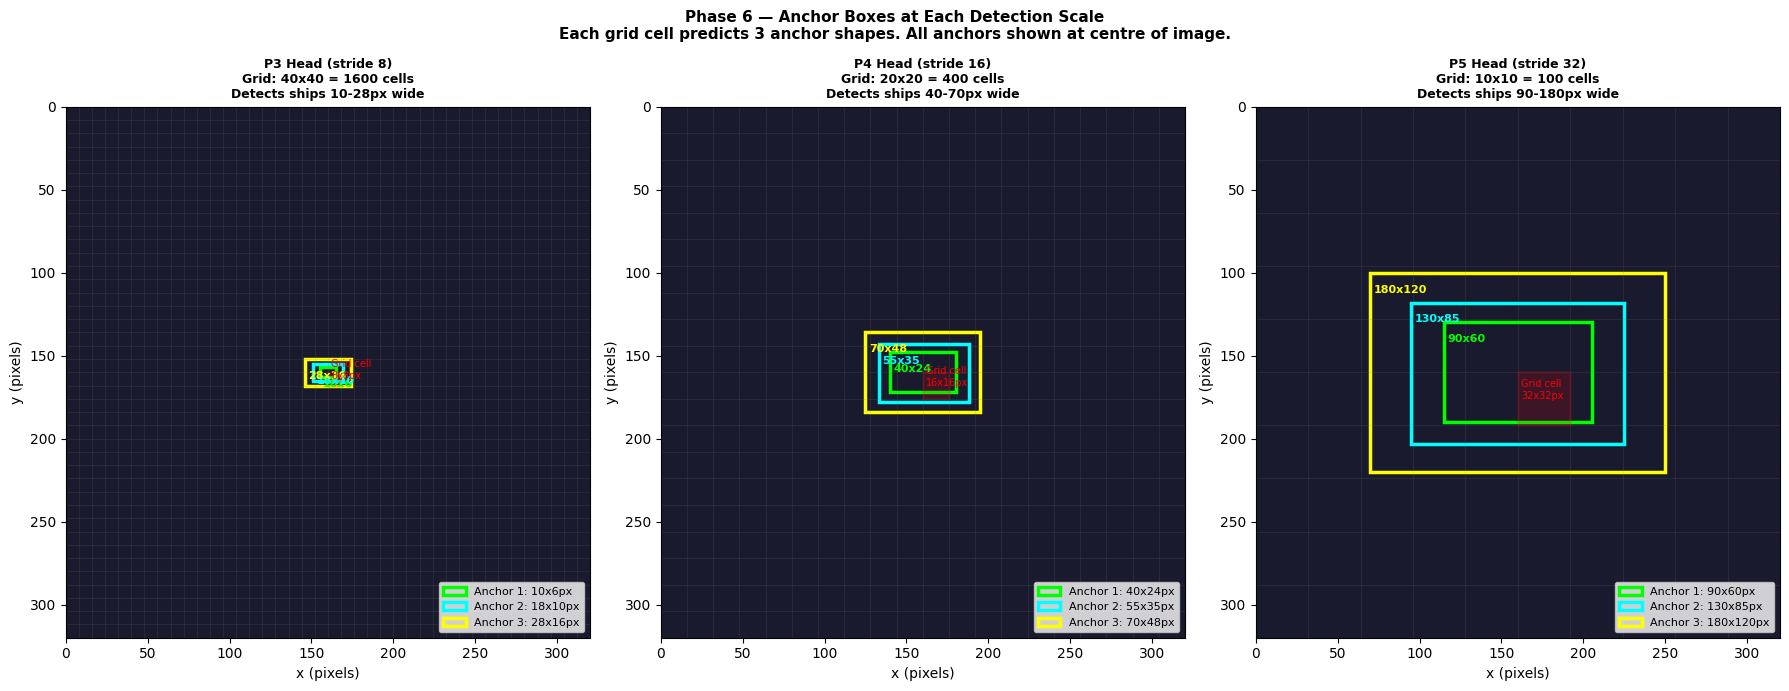

  Saved -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\phase6_outputs\anchor_boxes_visualisation.png


In [9]:
print('Visualising anchor boxes at each detection scale...')

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(
    'Phase 6 — Anchor Boxes at Each Detection Scale\n'
    'Each grid cell predicts 3 anchor shapes. '
    'All anchors shown at centre of image.',
    fontsize=11, fontweight='bold'
)

colors_anc = ['lime', 'cyan', 'yellow']

for col, (level, ancs) in enumerate(ANCHORS.items()):
    stride = STRIDES[level]
    grid   = IMG_H // stride
    ax     = axes[col]

    # Draw image background
    ax.set_facecolor('#1a1a2e')
    ax.set_xlim(0, IMG_W)
    ax.set_ylim(IMG_H, 0)  # flip y axis (image convention)

    # Draw grid lines
    for i in range(grid + 1):
        ax.axhline(i * stride, color='gray', alpha=0.2, linewidth=0.5)
        ax.axvline(i * stride, color='gray', alpha=0.2, linewidth=0.5)

    # Draw anchor boxes centred at image centre
    cx, cy = IMG_W // 2, IMG_H // 2
    for a_idx, (aw, ah) in enumerate(ancs):
        rect = patches.Rectangle(
            (cx - aw//2, cy - ah//2), aw, ah,
            linewidth=2.5, edgecolor=colors_anc[a_idx],
            facecolor='none',
            label=f'Anchor {a_idx+1}: {aw}x{ah}px'
        )
        ax.add_patch(rect)
        ax.text(cx - aw//2 + 2, cy - ah//2 + 12,
                f'{aw}x{ah}',
                fontsize=8, color=colors_anc[a_idx], fontweight='bold')

    # Highlight the grid cell at centre
    cell_cx = (cx // stride) * stride
    cell_cy = (cy // stride) * stride
    cell_rect = patches.Rectangle(
        (cell_cx, cell_cy), stride, stride,
        linewidth=2, edgecolor='red', facecolor='red', alpha=0.15
    )
    ax.add_patch(cell_rect)
    ax.text(cell_cx + 2, cell_cy + stride//2,
            f'Grid cell\n{stride}x{stride}px',
            fontsize=7, color='red')

    ax.set_title(
        f'{level} Head (stride {stride})\n'
        f'Grid: {grid}x{grid} = {grid*grid} cells\n'
        f'Detects ships {ancs[0][0]}-{ancs[-1][0]}px wide',
        fontsize=9, fontweight='bold'
    )
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')

plt.tight_layout()
p = os.path.join(OUT_DIR, 'anchor_boxes_visualisation.png')
plt.savefig(p, dpi=130, bbox_inches='tight')
plt.show()
print(f'  Saved -> {p}')

## Cell 10 — Complete Model Architecture Summary (Phases 4+5+6)

In [10]:
print('COMPLETE MODEL ARCHITECTURE — Phases 4 + 5 + 6')
print('=' * 65)
print()
print('  INPUT')
print(f'    SAR  image  [B, 1, {IMG_H}, {IMG_W}]')
print(f'    OPT  image  [B, 3, {IMG_H}, {IMG_W}]')
print()
print('  PHASE 4A — Dual-Stream Backbone')
print('    SAR  -> ResNet50  (1ch adapted, pretrained, early layers frozen)')
print(f'    Fs_P3 [B, 512,  {IMG_H//8},  {IMG_W//8} ]  stride 8')
print(f'    Fs_P4 [B, 1024, {IMG_H//16}, {IMG_W//16}]  stride 16')
print(f'    Fs_P5 [B, 2048, {IMG_H//32}, {IMG_W//32}]  stride 32')
print()
print('    OPT  -> CSPDarknet (3ch, early layers frozen)')
print(f'    Fo_P3 [B, 256,  {IMG_H//8},  {IMG_W//8} ]  stride 8')
print(f'    Fo_P4 [B, 512,  {IMG_H//16}, {IMG_W//16}]  stride 16')
print(f'    Fo_P5 [B, 1024, {IMG_H//32}, {IMG_W//32}]  stride 32')
print()
print('  PHASE 5 — CrossModalAttention + FPN')
print('    CMA_P3: Fs_P3 + Fo_P3  ->  F_P3 [B, 256, 40, 40]')
print('    CMA_P4: Fs_P4 + Fo_P4  ->  F_P4 [B, 256, 20, 20]')
print('    CMA_P5: Fs_P5 + Fo_P5  ->  F_P5 [B, 256, 10, 10]')
print('    FPN: P5->P4->P3 top-down enrichment')
print(f'    out_P3 [B, 256, {IMG_H//8},  {IMG_W//8} ]')
print(f'    out_P4 [B, 256, {IMG_H//16}, {IMG_W//16}]')
print(f'    out_P5 [B, 256, {IMG_H//32}, {IMG_W//32}]')
print()
print('  PHASE 6 — YOLO Detection Heads  <- CURRENT PHASE')
print('    head_P3(out_P3) -> pred_P3 [B, 18, 40, 40]  small ships')
print('    head_P4(out_P4) -> pred_P4 [B, 18, 20, 20]  medium ships')
print('    head_P5(out_P5) -> pred_P5 [B, 18, 10, 10]  large ships')
print()
print('  OUTPUT (per image, after decoding + NMS)')
print('    List of detected ships: [x_center, y_center, w, h, confidence]')
print()
print('─' * 65)
print('  PARAMETER COUNT SUMMARY')
print('─' * 65)
backbone_params  = 40_280_480
head_total, _    = detection_head.count_parameters()
print(f'  Phase 4A backbone  : ~{backbone_params:>12,}  params')
print(f'  Phase 5 fusion     : (see Phase 5 summary)')
print(f'  Phase 6 heads      : {head_total:>12,}  params')
print(f'  Heads are very lightweight ({head_total/backbone_params*100:.1f}% of backbone)')
print()
print('─' * 65)
print('  WHERE MODEL IS TRAINED (Phase 7)')
print('─' * 65)
print('  Dataset   : 193,460 paired SAR+optical images (from Phases 0-2)')
print('  Subset    : 9,000 train + 1,000 val (stratified, from Phase 3)')
print('  Epochs    : 20 (CPU hardware constraint)')
print('  Batch size: 4')
print('  Loss      : L_cls (BCE) + L_bbox (CIoU) + L_obj (BCE)')
print('  Optimiser : AdamW (lr=1e-3, weight_decay=0.01)')
print('  Scheduler : CosineAnnealingLR')
print('  The model learns to detect ships by minimising this loss')
print('  over 9,000 training pairs, evaluated on 1,000 val pairs.')

COMPLETE MODEL ARCHITECTURE — Phases 4 + 5 + 6

  INPUT
    SAR  image  [B, 1, 320, 320]
    OPT  image  [B, 3, 320, 320]

  PHASE 4A — Dual-Stream Backbone
    SAR  -> ResNet50  (1ch adapted, pretrained, early layers frozen)
    Fs_P3 [B, 512,  40,  40 ]  stride 8
    Fs_P4 [B, 1024, 20, 20]  stride 16
    Fs_P5 [B, 2048, 10, 10]  stride 32

    OPT  -> CSPDarknet (3ch, early layers frozen)
    Fo_P3 [B, 256,  40,  40 ]  stride 8
    Fo_P4 [B, 512,  20, 20]  stride 16
    Fo_P5 [B, 1024, 10, 10]  stride 32

  PHASE 5 — CrossModalAttention + FPN
    CMA_P3: Fs_P3 + Fo_P3  ->  F_P3 [B, 256, 40, 40]
    CMA_P4: Fs_P4 + Fo_P4  ->  F_P4 [B, 256, 20, 20]
    CMA_P5: Fs_P5 + Fo_P5  ->  F_P5 [B, 256, 10, 10]
    FPN: P5->P4->P3 top-down enrichment
    out_P3 [B, 256, 40,  40 ]
    out_P4 [B, 256, 20, 20]
    out_P5 [B, 256, 10, 10]

  PHASE 6 — YOLO Detection Heads  <- CURRENT PHASE
    head_P3(out_P3) -> pred_P3 [B, 18, 40, 40]  small ships
    head_P4(out_P4) -> pred_P4 [B, 18, 20, 20]  med

## Cell 11 — Final Summary Report

In [11]:
head_total, head_train = detection_head.count_parameters()

summary = [
    '=' * 65,
    'PHASE 6 - YOLO DETECTION HEAD - SUMMARY REPORT',
    f'Run at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    '=' * 65,
    '',
    'PROJECT: Multimodal Maritime Object Detection (SAR + Optical)',
    'Team: 22UG0005 | Panel: 5 | Guide: Mr. Nagesh Koundinya Subbanna',
    '',
    '-- WHAT PHASE 6 DOES --',
    'Converts fused feature maps from Phase 5 into actual ship predictions.',
    'Three parallel YOLO heads, one per pyramid level.',
    'Each head predicts bounding boxes + confidence for a ship size range.',
    '',
    '-- THREE DETECTION HEADS --',
    f'head_P3 (stride  8, grid 40x40): small ships  {ANCHORS["P3"]}',
    f'head_P4 (stride 16, grid 20x20): medium ships {ANCHORS["P4"]}',
    f'head_P5 (stride 32, grid 10x10): large ships  {ANCHORS["P5"]}',
    '',
    '-- OUTPUT FORMAT --',
    f'pred_P3 : [B, {OUT_CH}, {IMG_H//8},  {IMG_W//8} ]  raw logits',
    f'pred_P4 : [B, {OUT_CH}, {IMG_H//16}, {IMG_W//16}]  raw logits',
    f'pred_P5 : [B, {OUT_CH}, {IMG_H//32}, {IMG_W//32}]  raw logits',
    f'',
    f'Per prediction: tx, ty, tw, th, obj, cls',
    f'Total candidates per image: {NUM_ANCHORS*(IMG_H//8)*(IMG_W//8) + NUM_ANCHORS*(IMG_H//16)*(IMG_W//16) + NUM_ANCHORS*(IMG_H//32)*(IMG_W//32):,}',
    f'After NMS (conf>{CONF_THRESHOLD}, iou<{NMS_IOU_THRESH}): only best boxes kept',
    '',
    '-- PARAMETERS --',
    f'Total head params  : {head_total:,}',
    f'Trainable params   : {head_train:,}',
    '',
    '-- WHERE MODEL IS TRAINED --',
    'Phase 7 (next): Training Loop',
    'Dataset: 193,460 paired SAR+optical images from Phases 0-2',
    'Subset : 9,000 train + 1,000 val (stratified from Phase 3)',
    'Epochs : 20 (CPU hardware constraint)',
    'Loss   : L_cls (BCE) + L_bbox (CIoU) + L_obj (BCE)',
    'Model learns from pred_P3/P4/P5 compared to Phase 2 labels',
    '',
    '-- PANEL DEMO IMAGES SAVED --',
    '1. anchor_boxes_visualisation.png  (3 heads x 3 anchors at scale)',
    '',
    '-- NEXT STEP --',
    'Phase 7: Training Loop + Loss Functions',
    'Phases 4A + 5 + 6 assembled into one model and trained.',
    '=' * 65,
]

with open(SUMMARY_FILE, 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary))

print('\n'.join(summary))
print()
print(f'Summary saved -> {SUMMARY_FILE}')
print()
print('PHASE 6 COMPLETE!')
print(f'  pred_P3 : [B, {OUT_CH}, {IMG_H//8},  {IMG_W//8} ]  ready for Phase 7 loss')
print(f'  pred_P4 : [B, {OUT_CH}, {IMG_H//16}, {IMG_W//16}]  ready for Phase 7 loss')
print(f'  pred_P5 : [B, {OUT_CH}, {IMG_H//32}, {IMG_W//32}]  ready for Phase 7 loss')
print()
print('MODEL ARCHITECTURE COMPLETE (Phases 4A + 5 + 6).')
print('Next: Phase 7 — Training Loop where the model actually LEARNS.')

PHASE 6 - YOLO DETECTION HEAD - SUMMARY REPORT
Run at: 2026-05-01 14:21:19

PROJECT: Multimodal Maritime Object Detection (SAR + Optical)
Team: 22UG0005 | Panel: 5 | Guide: Mr. Nagesh Koundinya Subbanna

-- WHAT PHASE 6 DOES --
Converts fused feature maps from Phase 5 into actual ship predictions.
Three parallel YOLO heads, one per pyramid level.
Each head predicts bounding boxes + confidence for a ship size range.

-- THREE DETECTION HEADS --
head_P3 (stride  8, grid 40x40): small ships  [(10, 6), (18, 10), (28, 16)]
head_P4 (stride 16, grid 20x20): medium ships [(40, 24), (55, 35), (70, 48)]
head_P5 (stride 32, grid 10x10): large ships  [(90, 60), (130, 85), (180, 120)]

-- OUTPUT FORMAT --
pred_P3 : [B, 18, 40,  40 ]  raw logits
pred_P4 : [B, 18, 20, 20]  raw logits
pred_P5 : [B, 18, 10, 10]  raw logits

Per prediction: tx, ty, tw, th, obj, cls
Total candidates per image: 6,300
After NMS (conf>0.5, iou<0.45): only best boxes kept

-- PARAMETERS --
Total head params  : 1,784,886
Trai